ANALYSIS FOR FIRST DATASET

In [3]:
from google.colab import drive
import os
if not os.path.exists('/content/drive'):
  drive.mount('/content/drive')
else:
  print("Drive is already mounted.")


Mounted at /content/drive


In [4]:
import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/helpdesk_customer_multi_lang_tickets.csv')
print(data.head())

              id                                            subject  \
0  1001352387736  Urgent: Critical impact on enterprise network ...   
1  1004699418379     Intermittent Cursor Freezing Issue on Dell XPS   
2  1006966905046  Dringend: Unterstützung für die Datenwiederher...   
3  1009231330404           Anfrage zu den MacBook Air M1 Funktionen   
4  1024440081041  Solicitação de Assistência com Erro de Instala...   

                                                body  \
0  Dear Customer Support Team, We are experiencin...   
1  Dear Customer Support,<br><br>I hope this mess...   
2  Hallo, wir haben severe Datenverluste in MySQL...   
3  Sehr geehrtes Kundenserviceteam,\n\nich hoffe,...   
4  Caro Suporte ao Cliente,\n\nEstou enfrentando ...   

                                              answer      type  \
0  Subject: Re: Urgent: Critical impact on enterp...  Incident   
1  Dear <name>,\n\nThank you for reaching out reg...  Incident   
2  Hallo, vielen Dank, dass Sie uns ko

In [5]:
print(data.tail())

                 id                                            subject  \
1561  9974052734733                     Immediate Assistance Requested   
1562  9976062913094                 Demande de consultation de serveur   
1563  9980051846510                 Solicitação de Troca de Impressora   
1564  9982406203212  Problèmes de facturation concernant les servic...   
1565  9998324647529              Nouvelle configuration de projet Jira   

                                                   body  \
1561  Dear Customer Support Team,\n\nI am contacting...   
1562  Cher support client,\n\nJe vous écris pour dem...   
1563  Caro Suporte da Loja Online Tech,\n\nEstou enf...   
1564  Cher Service Client,\n\nJe vous écris pour por...   
1565  Cher service client,\n\nJe vous contacte pour ...   

                                                 answer     type  \
1561  Subject: Re: Immediate Assistance Requested\n\...  Request   
1562  Cher <name>,\n\nMerci de nous avoir contactés....  Request

In [6]:
data.columns

Index(['id', 'subject', 'body', 'answer', 'type', 'queue', 'priority',
       'language', 'business_type', 'tag_1', 'tag_2', 'tag_3', 'tag_4',
       'tag_5', 'tag_6', 'tag_7', 'tag_8', 'tag_9'],
      dtype='object')

In [7]:
data.describe()

,id,tag_9
count,1.566000e+03,0.0
mean,4.801366e+12,NaN
std,2.627746e+12,NaN
min,1.001352e+12,NaN
25%,2.506892e+12,NaN
50%,4.351363e+12,NaN
75%,7.014945e+12,NaN
max,9.998325e+12,NaN


In [8]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1566 entries, 0 to 1565
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             1566 non-null   int64  
 1   subject        1565 non-null   object 
 2   body           1565 non-null   object 
 3   answer         1566 non-null   object 
 4   type           1566 non-null   object 
 5   queue          1566 non-null   object 
 6   priority       1566 non-null   object 
 7   language       1566 non-null   object 
 8   business_type  1566 non-null   object 
 9   tag_1          1566 non-null   object 
 10  tag_2          1566 non-null   object 
 11  tag_3          1566 non-null   object 
 12  tag_4          1566 non-null   object 
 13  tag_5          1419 non-null   object 
 14  tag_6          1011 non-null   object 
 15  tag_7          489 non-null    object 
 16  tag_8          137 non-null    object 
 17  tag_9          0 non-null      float64
dtypes: float

In [9]:
data.isnull().sum()

,0
id,0
subject,1
body,1
answer,0
type,0
queue,0
priority,0
language,0
business_type,0
tag_1,0


In [10]:

data['queue'].value_counts()

,count
queue,
Technical Support,589
Product Support,288
Customer Service,234
IT Support,179
Billing and Payments,117
Sales and Pre-Sales,49
Returns and Exchanges,44
Service Outages and Maintenance,44
General Inquiry,13


In [11]:
data['business_type'].value_counts()

,count
business_type,
IT Services,748
Tech Online Store,528
IT Consulting Firm,189
Software Development Company,98
IT Consulting Service,3


In [12]:
data['subject'].value_counts()


,count
subject,
Urgent: Critical impact on enterprise network connectivity,1
Assistance requise pour la facturation,1
Problemas com o Roteador Cisco ISR4331,1
Problemas de conectividad intermitente en ISR4331,1
Abrechnungsdifferenz,1
...,...
Attention immédiate requise,1
Request for Cost-Effective AWS Management Solutions,1
Critical: Problem with AWS Deployment,1


In [13]:
data['type'].value_counts()


,count
type,
Incident,663
Request,468
Problem,292
Change,143


In [14]:
data['language'].value_counts()

,count
language,
de,397
es,379
en,339
pt,229
fr,222


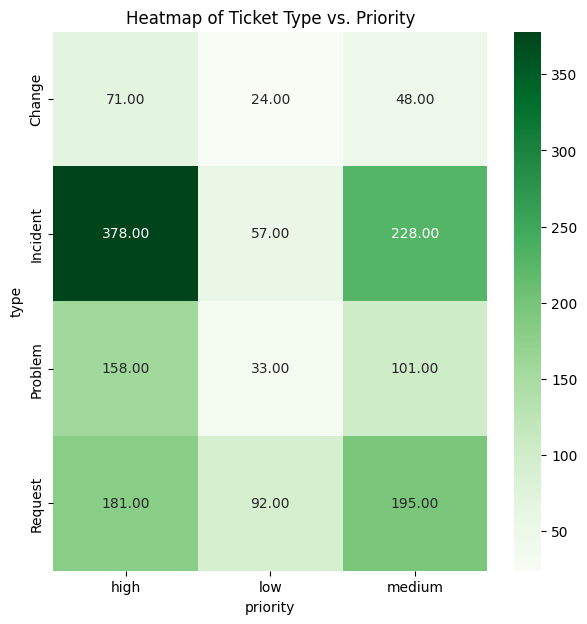

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'type' not in data.columns or 'priority' not in data.columns:
    raise ValueError("Not containing desired columns")


data.dropna(subset=['type', 'priority'], inplace=True)
if data.empty:
    print("Data Frame is empty ")
else:
  ticket_cross = pd.crosstab(data['type'], data['priority'])
plt.figure(figsize=(7,7))
sns.heatmap(ticket_cross, annot=True, fmt="0.2f", cmap="Greens")
plt.title('Heatmap of Ticket Type vs. Priority')
plt.xlabel('priority')
plt.ylabel('type')
plt.show()

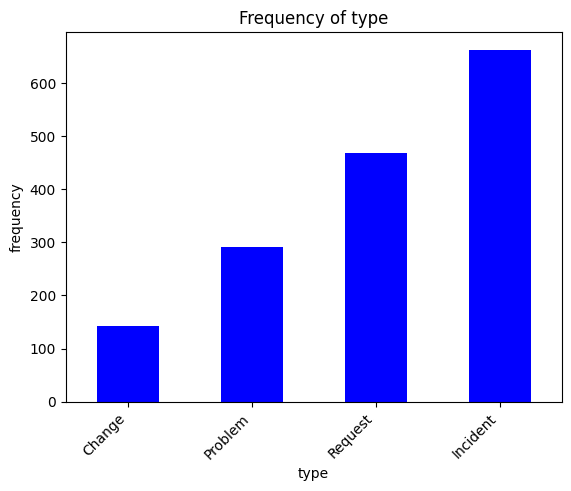

In [16]:
import matplotlib.pyplot as plt
data['type'].value_counts(ascending=True).plot(kind='bar', color='blue')
plt.xticks(rotation=45,ha='right')
plt.xlabel('type')
plt.ylabel('frequency')
_ = plt.title('Frequency of type')

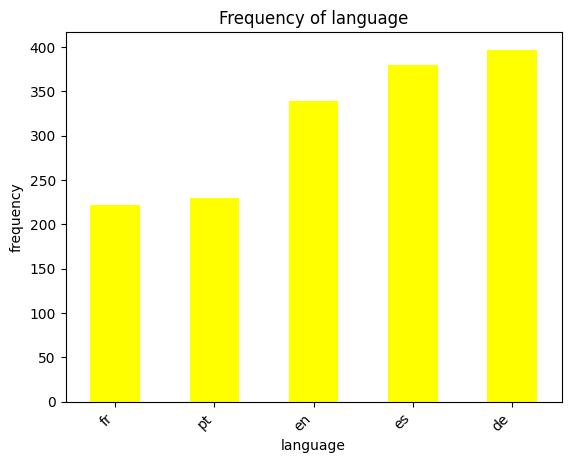

In [17]:
import matplotlib.pyplot as plt
data['language'].value_counts(ascending=True).plot(kind='bar', color='yellow')
plt.xticks(rotation=45,ha='right')
plt.xlabel('language')
plt.ylabel('frequency')
_ = plt.title('Frequency of language')

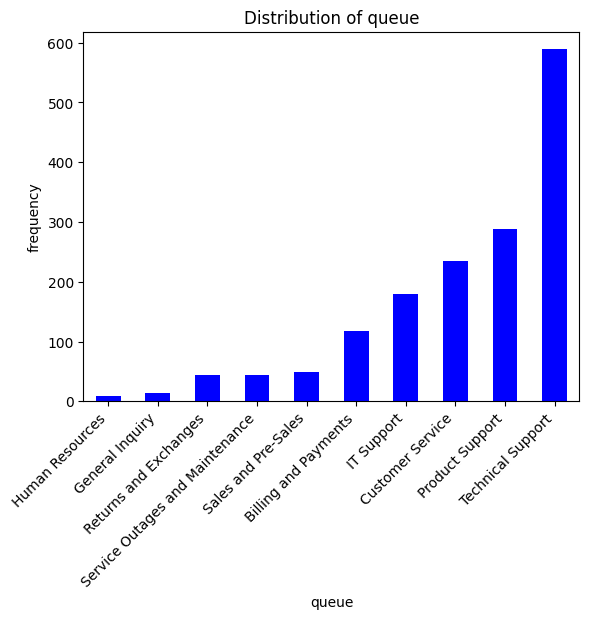

In [18]:
import matplotlib.pyplot as plt
data['queue'].value_counts(ascending=True).plot(kind='bar', color='blue')
plt.xticks(rotation=45,ha='right')
plt.xlabel('queue')
plt.ylabel('frequency')
_ = plt.title('Distribution of queue')

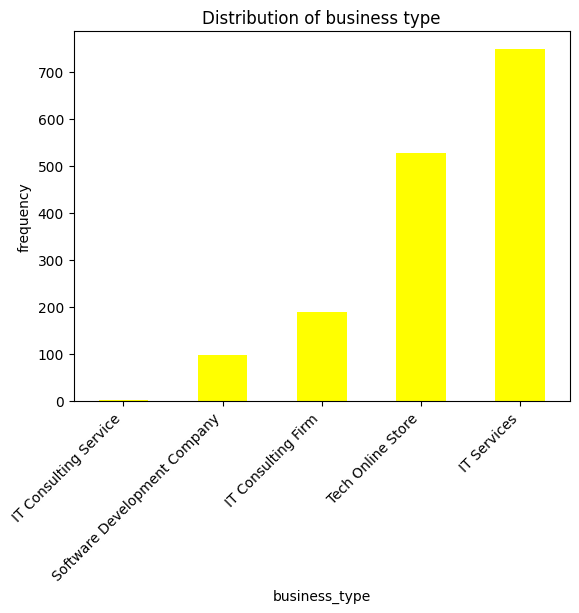

In [19]:
import matplotlib.pyplot as plt
data['business_type'].value_counts(ascending=True).plot(kind='bar', color='yellow')
plt.xticks(rotation=45,ha='right')
plt.xlabel('business_type')
plt.ylabel('frequency')
_ = plt.title('Distribution of business type')

In [22]:
histo= data.groupby('type')['priority'].value_counts()
print(histo)

type      priority
Change    high         71
          medium       48
          low          24
Incident  high        378
          medium      228
          low          57
Problem   high        158
          medium      101
          low          33
Request   medium      195
          high        181
          low          92
Name: count, dtype: int64


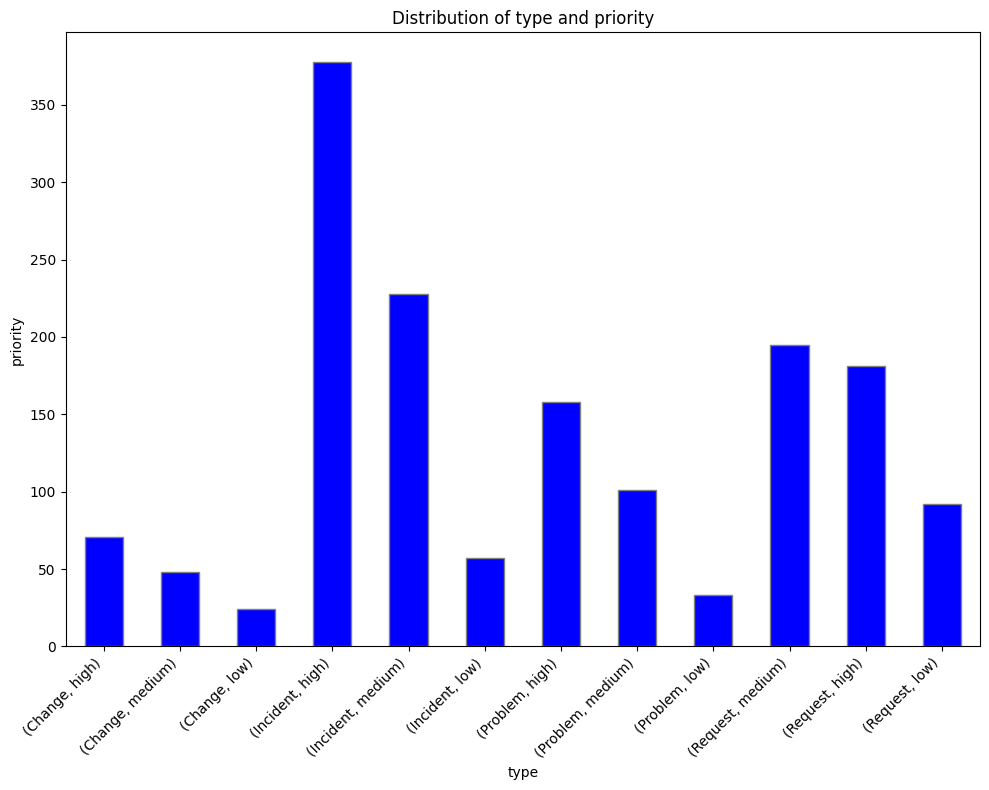

In [23]:
plt.figure(figsize=(10,8))
histo.plot(kind= 'bar', color='blue', edgecolor= 'grey')
plt.xlabel('type')
plt.ylabel('priority')
plt.title('Distribution of type and priority')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

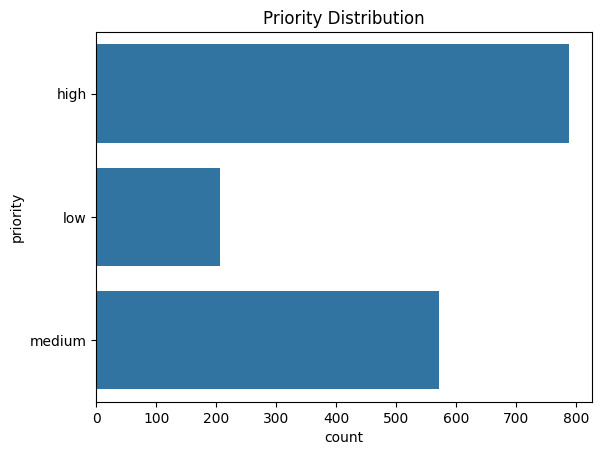

In [24]:
sns.countplot(data['priority'])
plt.title('Priority Distribution')
plt.show()

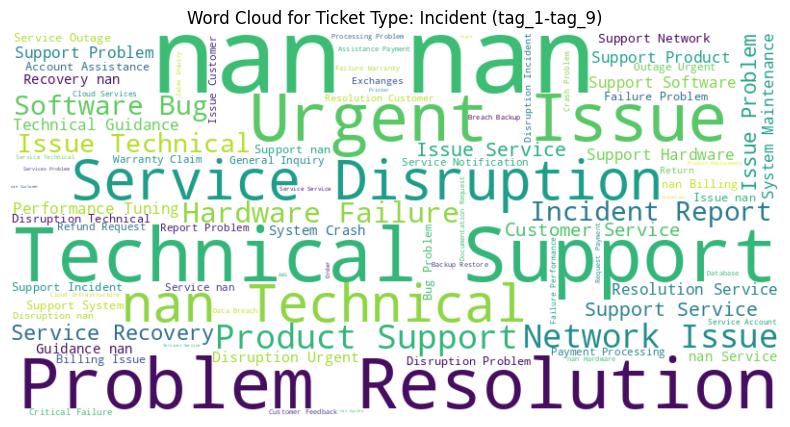

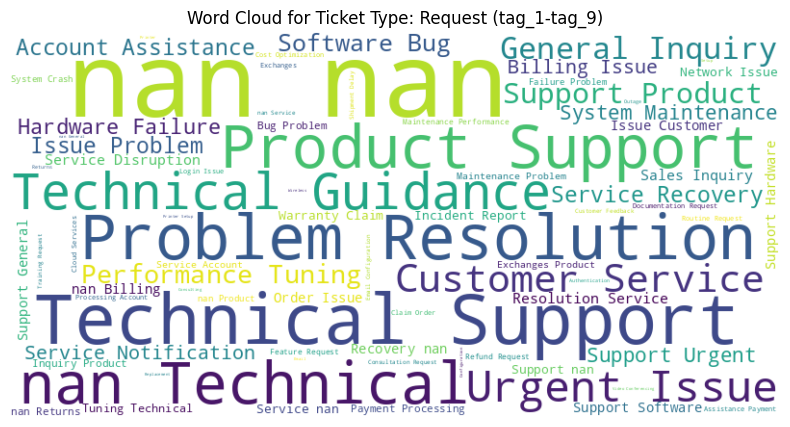

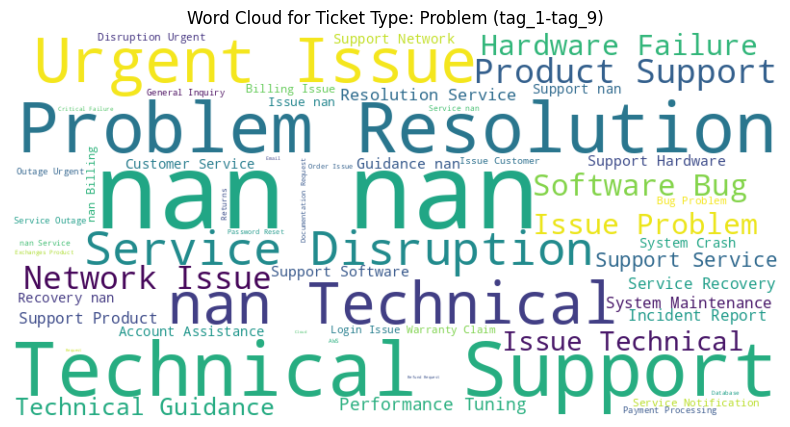

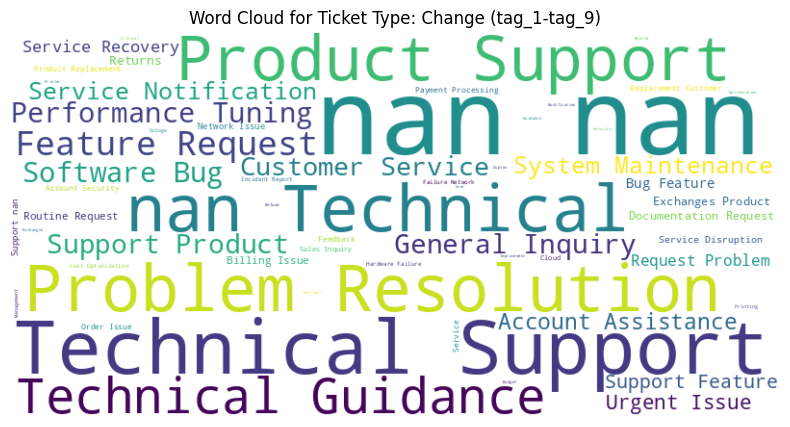

In [29]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

unique_ticket_types = data['type'].unique()

# Iterate through each unique ticket type
for ticket_type in unique_ticket_types:
    subset = data[data['type'] == ticket_type]

    # Combine text from 'tag_1' to 'tag_9' columns
    tag_columns = [f'tag_{i}' for i in range(1, 10)]  # Changed to 'tag_'
    text = ' '.join(subset[tag_columns].astype(str).values.flatten())

    # Generate the word cloud
    wordcloud = WordCloud(width=800, height=400,
                          background_color='white',
                          stopwords=STOPWORDS).generate(text)

    # Display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for Ticket Type: {ticket_type} (tag_1-tag_9)') # Updated title
    plt.show()

ANALYSIS FOR SECOND DATASET


In [33]:
import pandas as pd

df = pd.read_parquet('/content/train-00000-of-00001-a5a7c6e4bb30b016.parquet')
df.head()

,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation
0,Login and Account,Mobile Number and Email Verification,Verification requirement for mobile number or ...,Mobile Number and Email Verification -> Verifi...,neutral,Appliances,Oven Toaster Grills (OTG),medium,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox Customer...
1,Cancellations and returns,Pickup and Shipping,Reasons for being asked to ship the item,Pickup and Shipping -> Reasons for being asked...,neutral,Electronics,Computer Monitor,less,junior,"handles customer inquiries independently, poss...",Agent: Thank you for calling BrownBox customer...
2,Cancellations and returns,Replacement and Return Process,Inability to click the 'Cancel' button,Replacement and Return Process -> Inability to...,neutral,Appliances,Juicer/Mixer/Grinder,medium,experienced,"confidently handles complex customer issues, e...",Agent: Thank you for calling BrownBox Customer...
3,Login and Account,Login Issues and Error Messages,Error message regarding exceeded attempts to e...,Login Issues and Error Messages -> Error messa...,neutral,Appliances,Water Purifier,less,inexperienced,"may struggle with ambiguous queries, rely on c...","Customer: Hi, I am facing an issue while loggi..."
4,Order,Order Delivery Issues,Delivery not attempted again,Order Delivery Issues -> Delivery not attempte...,negative,Electronics,Bp Monitor,medium,experienced,"confidently handles complex customer issues, e...",Agent: Thank you for contacting BrownBox custo...


In [34]:
df.shape

(1000, 11)

In [35]:
# Function to count unique values and display them
def unique_value_counts(df):
    for col in df.columns:
        unique_counts = df[col].value_counts()
        print(f"Column: {col}")
        print(f"Unique Value Counts:\n{unique_counts}")
        print("-" * 20)

unique_value_counts(data)

Column: id
Unique Value Counts:
id
1001352387736    1
5930411665534    1
6136745370908    1
6131709796559    1
6126111047744    1
                ..
3021256324896    1
3012141762801    1
3011993580237    1
3009980785588    1
9998324647529    1
Name: count, Length: 1566, dtype: int64
--------------------
Column: subject
Unique Value Counts:
subject
Urgent: Critical impact on enterprise network connectivity    1
Assistance requise pour la facturation                        1
Problemas com o Roteador Cisco ISR4331                        1
Problemas de conectividad intermitente en ISR4331             1
Abrechnungsdifferenz                                          1
                                                             ..
Attention immédiate requise                                   1
Request for Cost-Effective AWS Management Solutions           1
Critical: Problem with AWS Deployment                         1
Asistencia para Problemas de Arranque                         1
Nouvelle c


Analyzing column: type
Value Counts:
type
Incident    663
Request     468
Problem     292
Change      143
Name: count, dtype: int64


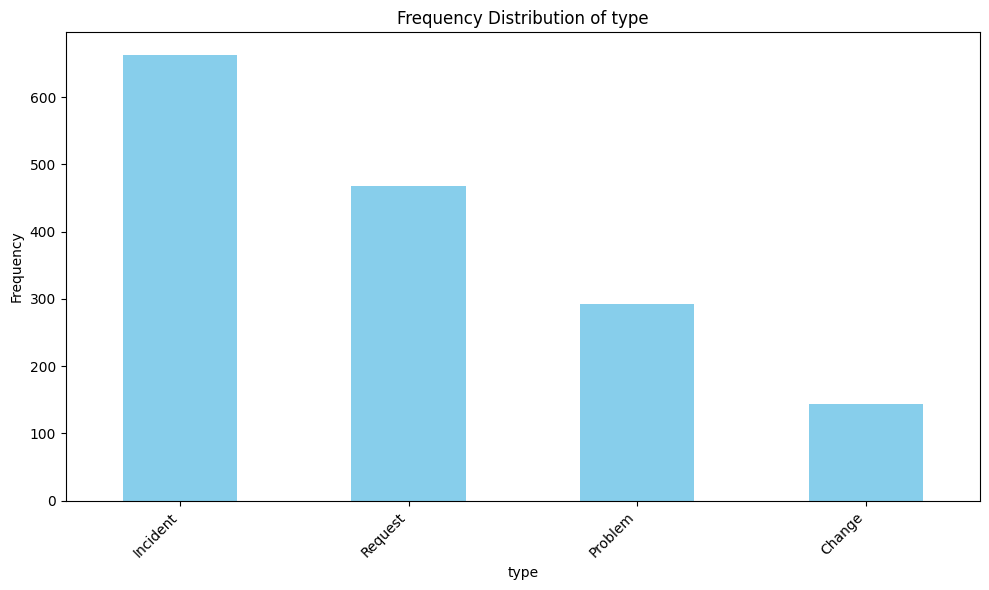


Analyzing column: priority
Value Counts:
priority
high      788
medium    572
low       206
Name: count, dtype: int64


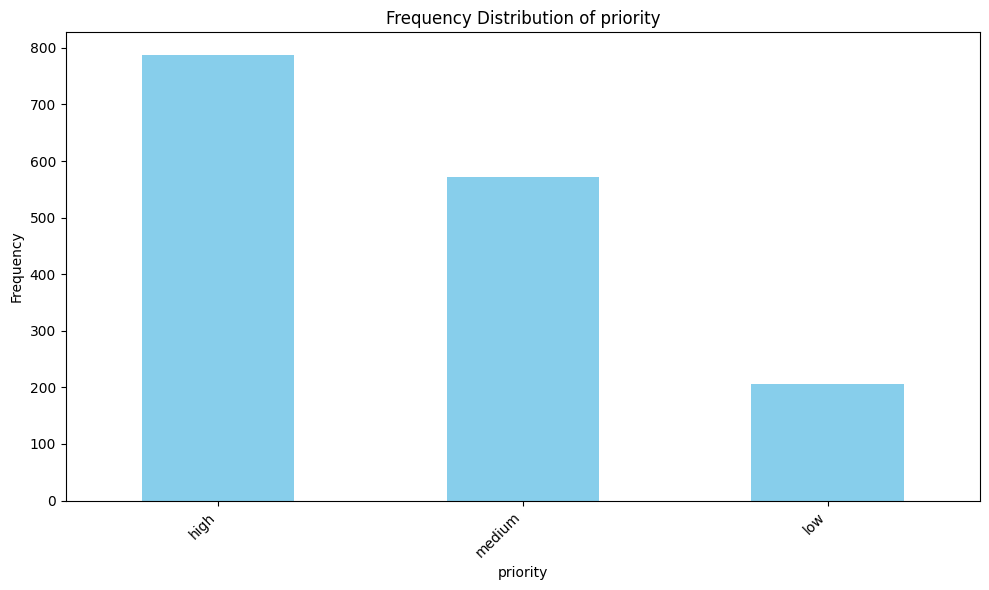


Analyzing column: language
Value Counts:
language
de    397
es    379
en    339
pt    229
fr    222
Name: count, dtype: int64


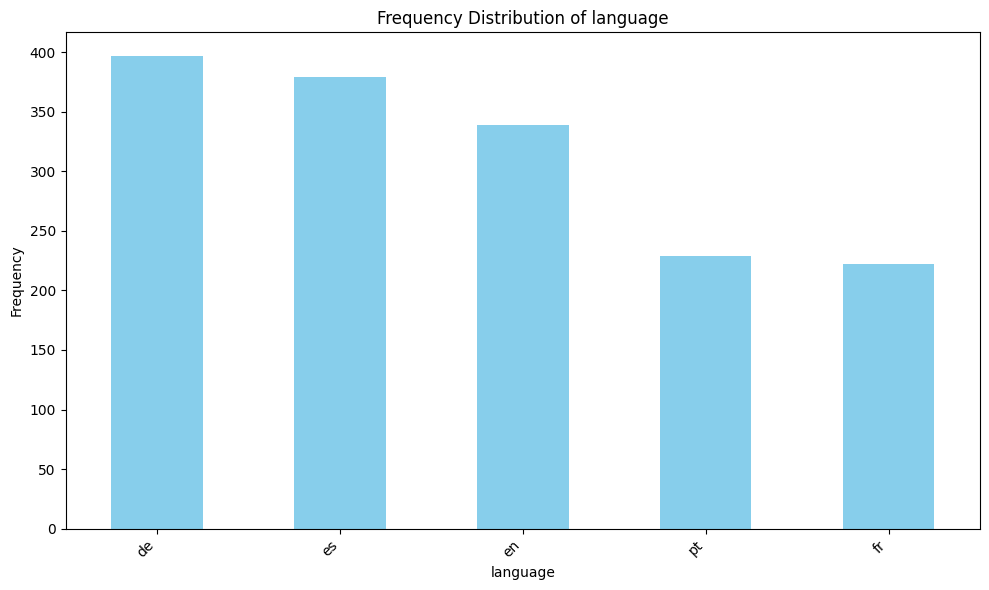


Analyzing column: queue
Value Counts:
queue
Technical Support                  589
Product Support                    288
Customer Service                   234
IT Support                         179
Billing and Payments               117
Sales and Pre-Sales                 49
Returns and Exchanges               44
Service Outages and Maintenance     44
General Inquiry                     13
Human Resources                      9
Name: count, dtype: int64


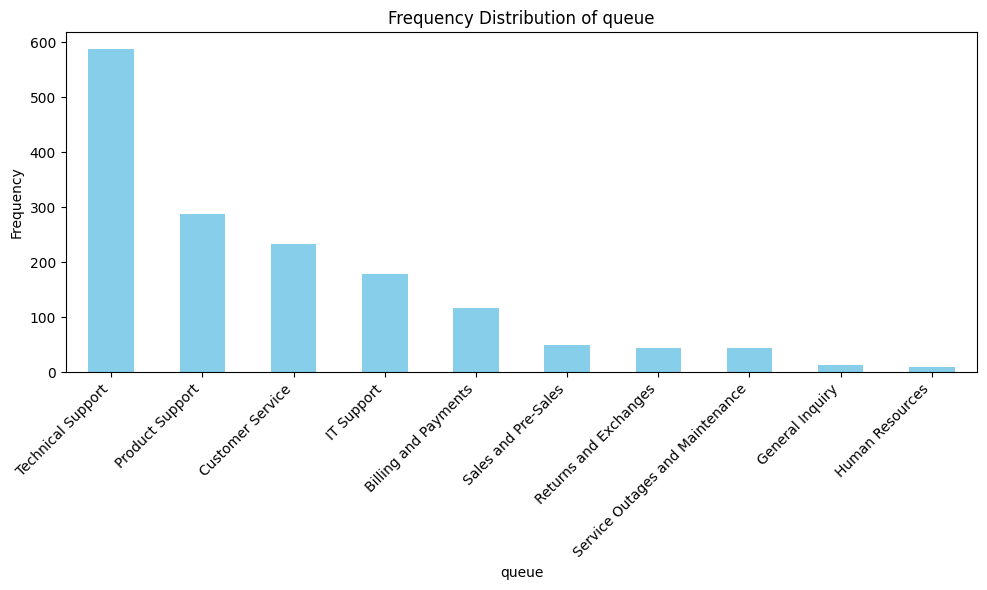


Analyzing column: business_type
Value Counts:
business_type
IT Services                     748
Tech Online Store               528
IT Consulting Firm              189
Software Development Company     98
IT Consulting Service             3
Name: count, dtype: int64


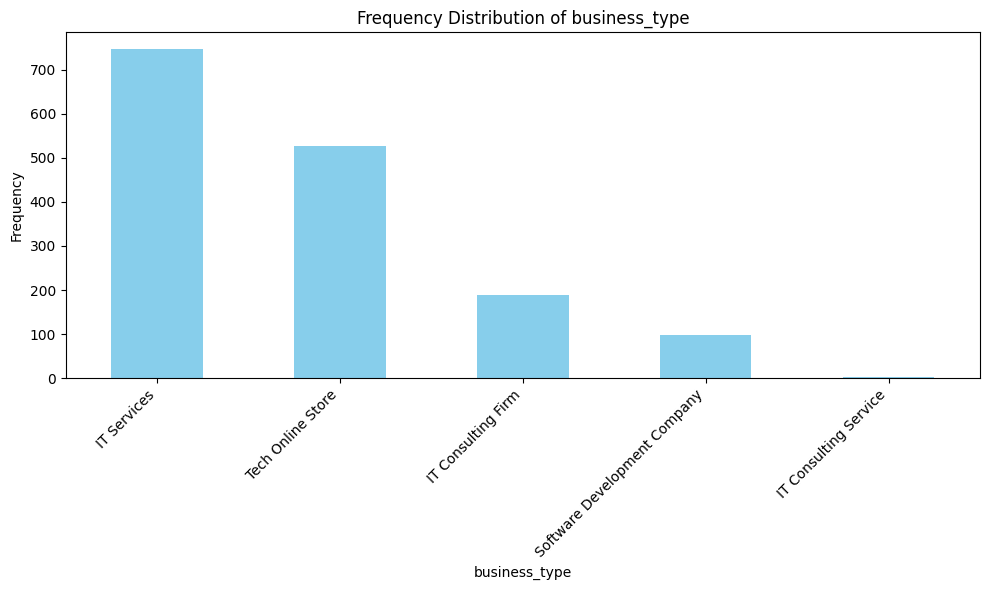

In [37]:
def analyze_categorical_distributions(df, column_list):
    """
    Analyzes and visualizes the frequency distributions of specified categorical columns in a DataFrame.

    Args:
        df: The input DataFrame.
        column_list: A list of column names to analyze.
    """

    for col in column_list:
        if col not in df.columns:
            print(f"Warning: Column '{col}' not found in DataFrame.")
            continue

        print(f"\nAnalyzing column: {col}")
        value_counts = df[col].value_counts()
        print("Value Counts:")
        print(value_counts)

        plt.figure(figsize=(10, 6))  # Adjust figure size as needed
        value_counts.plot(kind='bar', color='skyblue')
        plt.title(f'Frequency Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

# Example usage (replace with the actual columns you want to analyze)
categorical_cols = ['type', 'priority', 'language', 'queue', 'business_type']
analyze_categorical_distributions(data, categorical_cols)

In [38]:
df.columns

Index(['issue_area', 'issue_category', 'issue_sub_category',
       'issue_category_sub_category', 'customer_sentiment', 'product_category',
       'product_sub_category', 'issue_complexity', 'agent_experience_level',
       'agent_experience_level_desc', 'conversation'],
      dtype='object')

In [39]:
df.describe()

,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,6,40,109,109,4,3,50,3,3,3,998
top,Cancellations and returns,Return and Exchange,Verification requirement for mobile number or ...,Mobile Number and Email Verification -> Verifi...,neutral,Appliances,Vacuum Cleaner,less,junior,"handles customer inquiries independently, poss...","Agent: You're welcome, Jane. Have a great day!"
freq,286,95,17,17,552,465,28,488,507,507,3


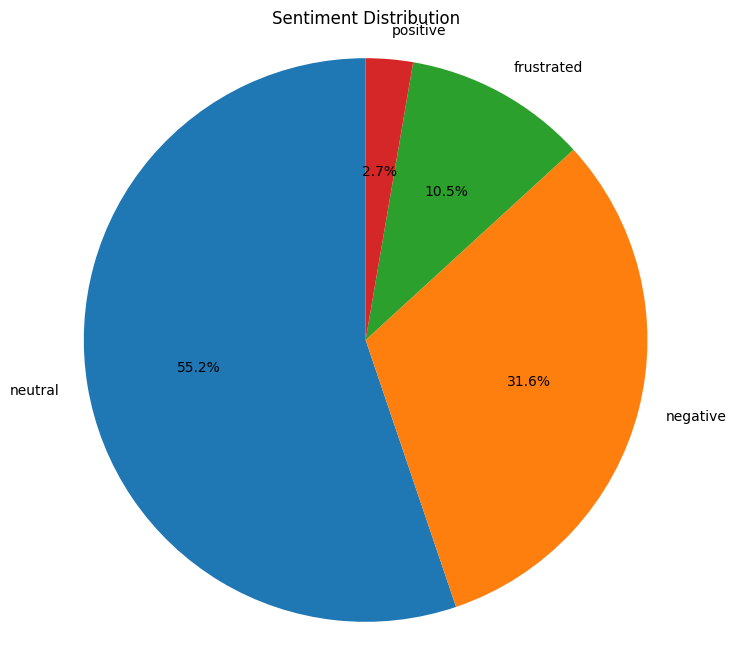

In [42]:
#pie chart for sentiment distribution
import matplotlib.pyplot as plt

sentiment_counts = df['customer_sentiment'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Sentiment Distribution')
plt.axis('equal')
plt.show()

In [43]:
# prompt: Group data by issue_area and calculate the proportion of each customer_sentiment for each area.

# Calculate the proportion of each customer_sentiment for each issue_area
sentiment_proportions = df.groupby('issue_area')['customer_sentiment'].value_counts(normalize=True).unstack()

# Display the proportions
sentiment_proportions

customer_sentiment,frustrated,negative,neutral,positive
issue_area,,,,
Cancellations and returns,0.146853,0.349650,0.503497,NaN
Login and Account,NaN,0.192053,0.807947,NaN
Order,0.140741,0.440741,0.318519,0.1
Shipping,NaN,0.527778,0.472222,NaN
Shopping,0.129310,0.189655,0.681034,NaN
Warranty,0.095238,0.076190,0.828571,NaN


In [44]:
crosstab = pd.crosstab(df['issue_area'], df['product_category'])
print(crosstab)

product_category           Appliances  Electronics  Men/Women/Kids
issue_area                                                        
Cancellations and returns         136           88              62
Login and Account                  65           44              42
Order                             107           79              84
Shipping                           35           22              15
Shopping                           52           35              29
Warranty                           70           35               0


In [45]:
# Group by issue category and sub-category, then count negative sentiments
negative_sentiment_counts = df[df['customer_sentiment'] == 'negative'].groupby(['issue_category', 'issue_sub_category'])['customer_sentiment'].count()

# Sort the counts in descending order to find the most frequent negative sentiment combinations
negative_sentiment_counts_sorted = negative_sentiment_counts.sort_values(ascending=False)

# Print or further analyze the sorted counts
negative_sentiment_counts_sorted

,,customer_sentiment
issue_category,issue_sub_category,
Mobile Number and Email Verification,Issues with receiving the OTP or verification code,15
Account Reactivation and Deactivation,Reactivating an inactive account,14
Returns and Refunds,Service center denial of repair request,14
Pickup and Shipping,Changing the address for item pick-up,14
Product Availability for Shipping,"Inability to order specific products (e.g., television, air-conditioner, refrigerator, washing machine, furniture, microwave, treadmill) at a location",13
Availability of Faster Delivery Options,Unavailability of faster delivery options at a specific location,12
Return and Exchange,Package open or tampered on delivery,12
Return Checks and Fees,Determination of the Return Fee,12
Order Delivery Issues,Delivery not attempted again,11


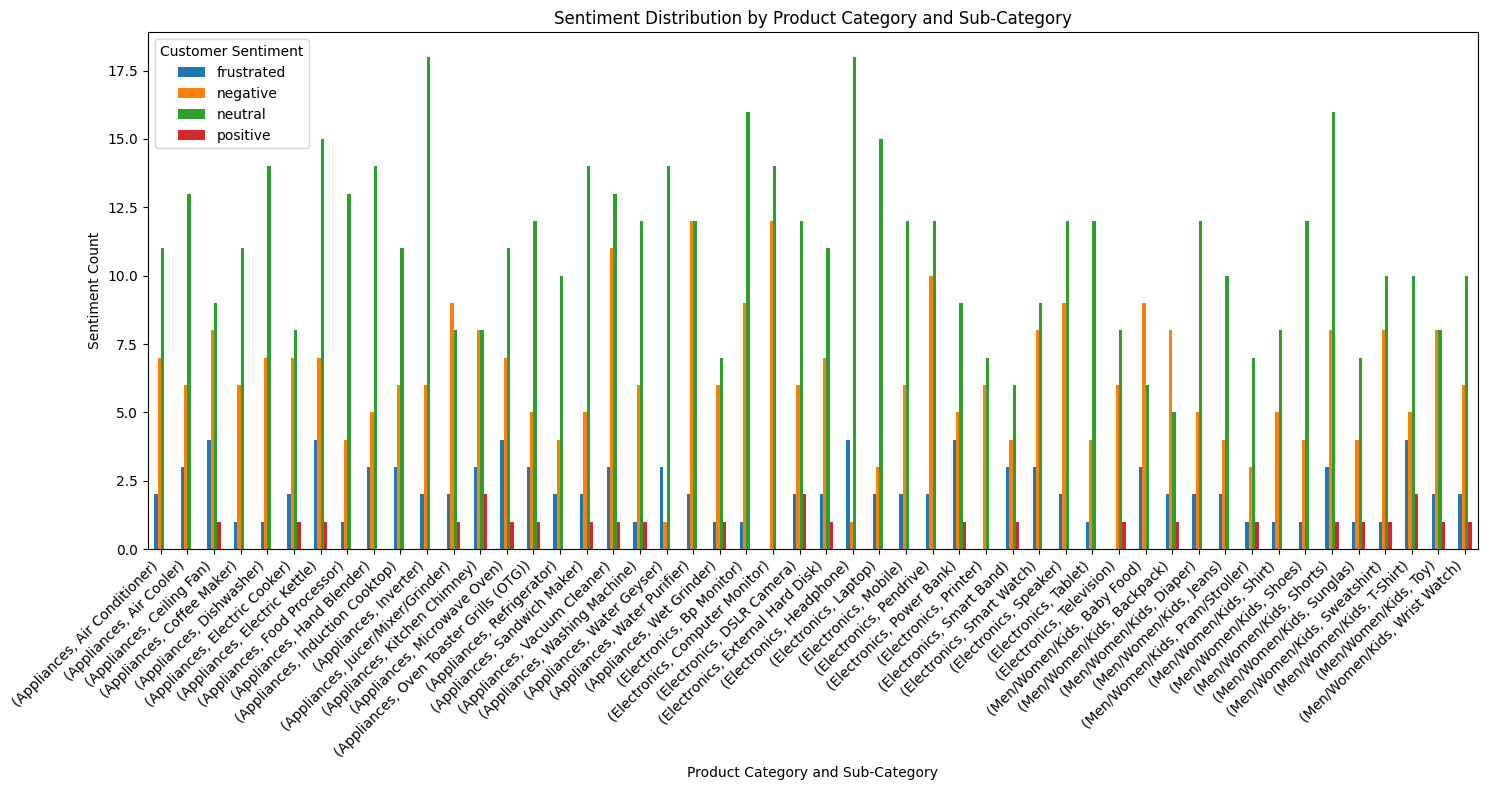

In [46]:
# prompt: Analyze sentiment distribution for each product_category and product_sub_category. and draw bar chart

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'df' is your DataFrame from the previous code
# and it contains 'product_category', 'product_sub_category', and 'customer_sentiment' columns

# Group by product category and sub-category, then count sentiments
sentiment_distribution = df.groupby(['product_category', 'product_sub_category'])['customer_sentiment'].value_counts().unstack(fill_value=0)

# Plot the sentiment distribution for each category and sub-category
sentiment_distribution.plot(kind='bar', figsize=(15, 8))
plt.title('Sentiment Distribution by Product Category and Sub-Category')
plt.xlabel('Product Category and Sub-Category')
plt.ylabel('Sentiment Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Customer Sentiment')
plt.tight_layout()
plt.show()

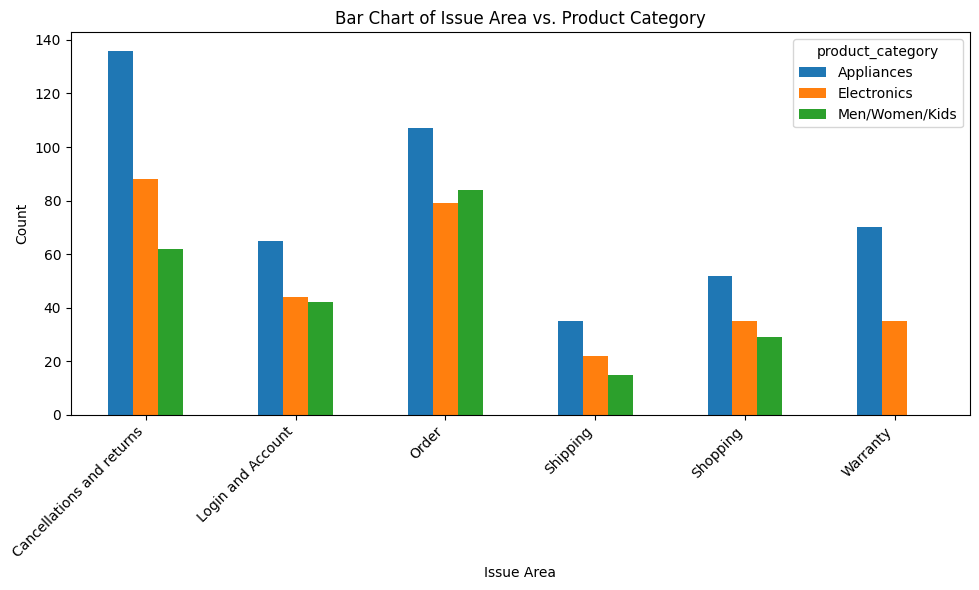

In [47]:
#bar chart between issue area and product category column
crosstab = pd.crosstab(df['issue_area'], df['product_category'])
crosstab.plot(kind='bar', figsize=(10, 6))
plt.title('Bar Chart of Issue Area vs. Product Category')
plt.xlabel('Issue Area')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

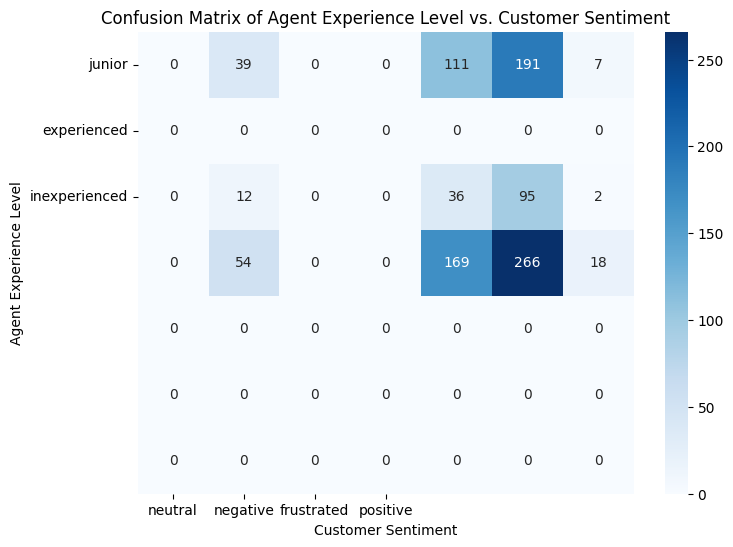

In [48]:
#create a confusion matrix for agent experience level and customer sentimenet

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(df['agent_experience_level'], df['customer_sentiment'])

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=df['customer_sentiment'].unique(),
            yticklabels=df['agent_experience_level'].unique())
plt.title('Confusion Matrix of Agent Experience Level vs. Customer Sentiment')
plt.xlabel('Customer Sentiment')
plt.ylabel('Agent Experience Level')
plt.show()

In [49]:
mydata = df[['customer_sentiment','conversation']]
mydata.head()

,customer_sentiment,conversation
0,neutral,Agent: Thank you for calling BrownBox Customer...
1,neutral,Agent: Thank you for calling BrownBox customer...
2,neutral,Agent: Thank you for calling BrownBox Customer...
3,neutral,"Customer: Hi, I am facing an issue while loggi..."
4,negative,Agent: Thank you for contacting BrownBox custo...


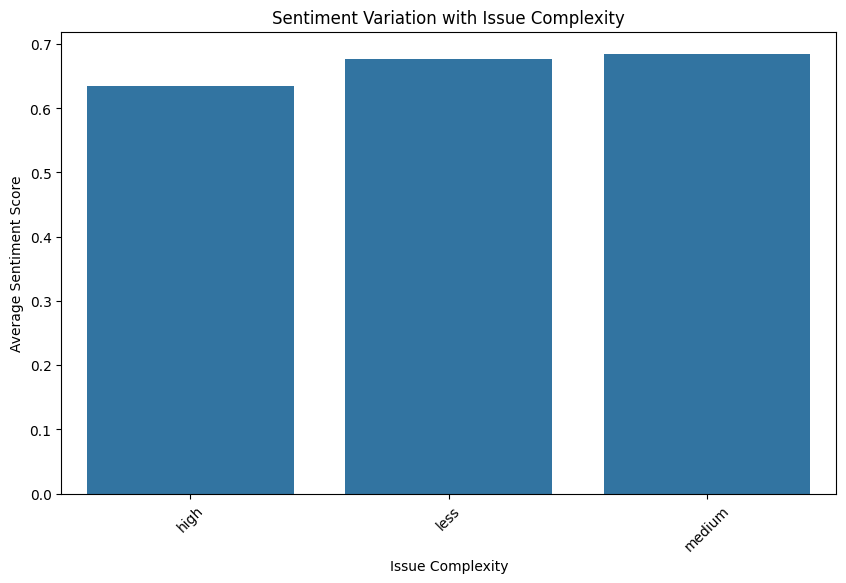

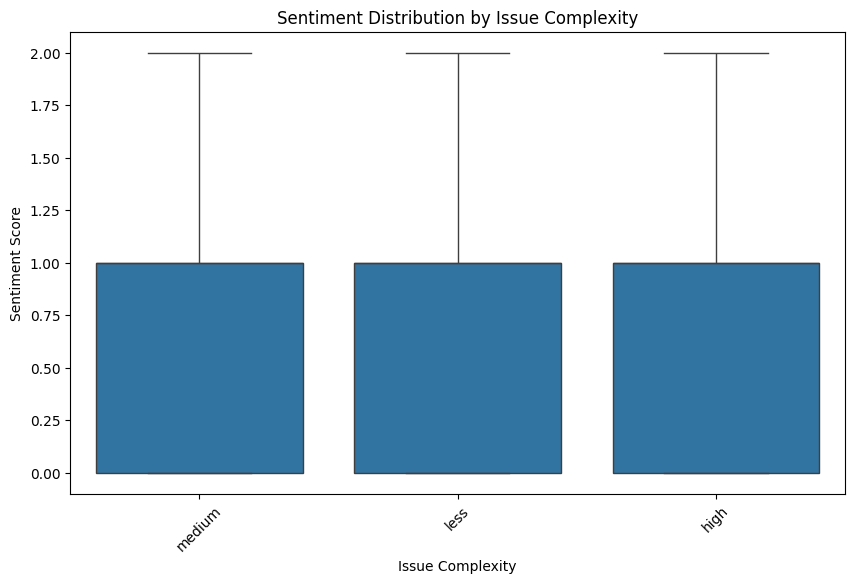

In [50]:
# prompt: Analyze how sentiment varies with issue_complexity

import matplotlib.pyplot as plt
import seaborn as sns

# If customer_sentiment is categorical:
sentiment_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}  # Example mapping
df['sentiment_score'] = df['customer_sentiment'].map(sentiment_mapping)


# Group by 'issue_complexity' and calculate the mean sentiment score
sentiment_by_complexity = df.groupby('issue_complexity')['sentiment_score'].mean()

# Create a bar plot to visualize the relationship
plt.figure(figsize=(10, 6))
sns.barplot(x=sentiment_by_complexity.index, y=sentiment_by_complexity.values)
plt.xlabel('Issue Complexity')
plt.ylabel('Average Sentiment Score')
plt.title('Sentiment Variation with Issue Complexity')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability if needed
plt.show()


# Alternative visualization: Box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='issue_complexity', y='sentiment_score', data=df)
plt.xlabel('Issue Complexity')
plt.ylabel('Sentiment Score')
plt.title('Sentiment Distribution by Issue Complexity')
plt.xticks(rotation=45)
plt.show()

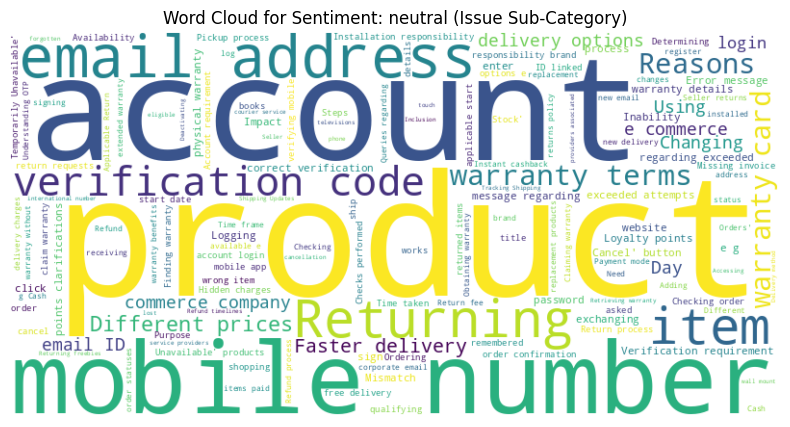

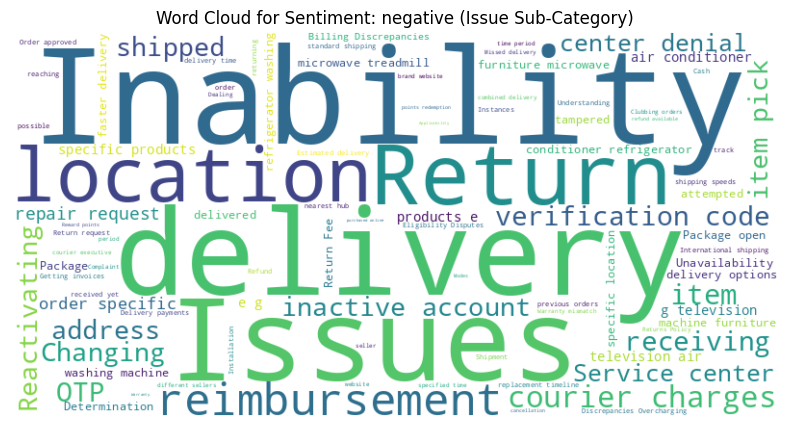

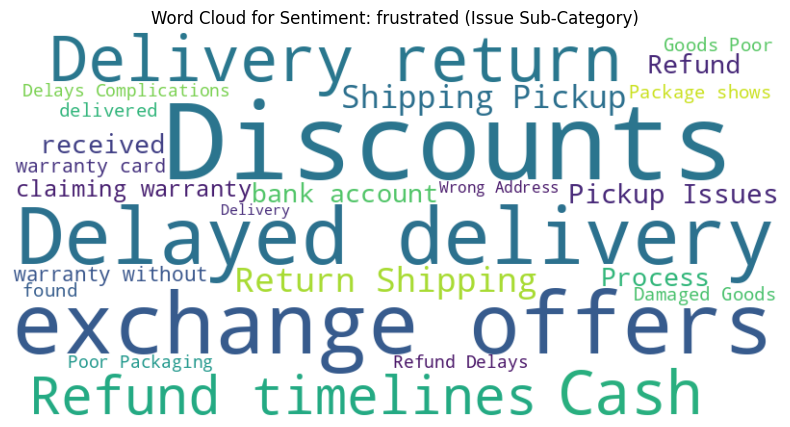

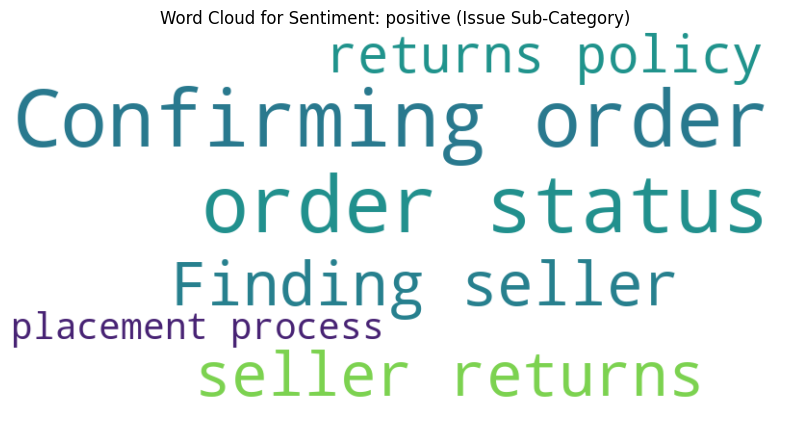

In [52]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

def plot_wordcloud_by_sentiment(df):
    """Generates word clouds for issue_sub_category for different sentiments."""

    for sentiment in df['customer_sentiment'].unique():
        subset = df[df['customer_sentiment'] == sentiment]
        text = ' '.join(subset['issue_sub_category'].astype(str).values.flatten())
        wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(text)
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Word Cloud for Sentiment: {sentiment} (Issue Sub-Category)')
        plt.show()

plot_wordcloud_by_sentiment(df)